# [LAB 09] 4. 다중선형회귀
## #연습문제
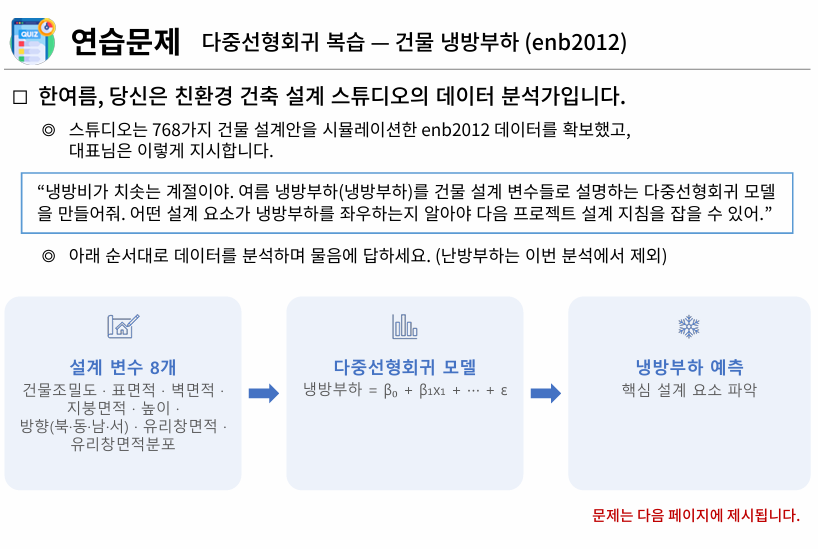
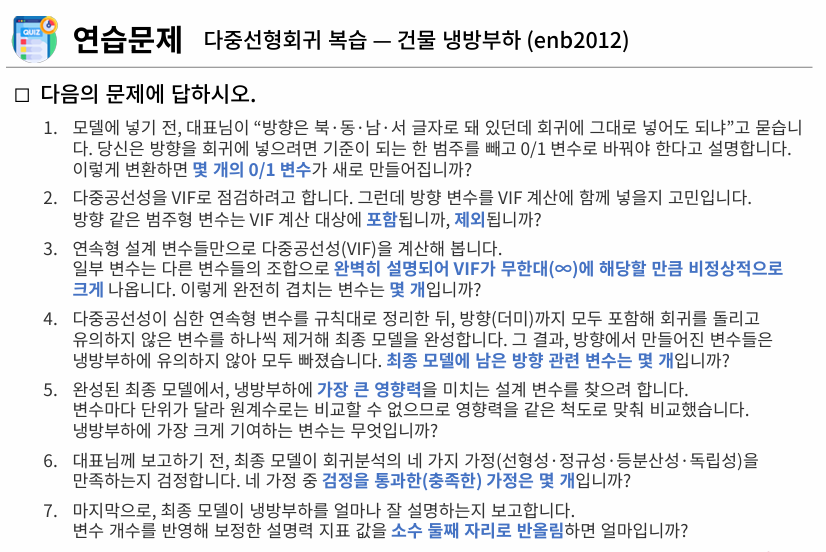

In [22]:
# 라이브러리 참조
from hossam import load_data
from helpers import *

import numpy as np
from pandas import DataFrame, get_dummies
from IPython.display import display, Markdown

In [23]:
origin = load_data('enb2012')
origin.head()

📚 이 데이터 세트는 토목/구조 엔지니어인 Angeliki Xifara(angxifara@gmail.com)가 생성했으며, 영국 옥스퍼드 대학교 산업 및 응용 수학 센터의 Athanasios Tsanas(tsanasthanasis@gmail.com)가 처리했습니다.

본 연구에서는 Ecotect를 이용하여 12가지 서로 다른 건물 형태를 시뮬레이션하고 에너지 분석을 수행했습니다.

건물들은 유리창 면적, 유리창 면적 분포, 방향 등 여러 매개변수에서 차이를 보입니다.

이러한 특성들을 함수로 하여 다양한 설정을 시뮬레이션함으로써 총 768가지 건물 형태를 얻었습니다.

데이터셋은 768개의 샘플과 8개의 특징으로 구성되며, 두 개의 실수 값을 갖는 응답값을 예측하는 것을 목표로 합니다.

(출처: https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset)

A. Tsanas, A. Xifara: 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools', Energy and Buildings, Vol. 49, pp. 560-567, 2012


,건물조밀도,표면적,벽면적,지붕면적,높이,방향,유리창면적,유리창면적분포,난방부하,냉방부하
0,0.980,514.500,294.000,110.250,7.000,북,0.000,0,15.550,21.330
1,0.980,514.500,294.000,110.250,7.000,동,0.000,0,15.550,21.330
2,0.980,514.500,294.000,110.250,7.000,남,0.000,0,15.550,21.330
3,0.980,514.500,294.000,110.250,7.000,서,0.000,0,15.550,21.330
4,0.900,563.500,318.500,122.500,7.000,북,0.000,0,20.840,28.280


In [24]:
df = origin.copy()
df = df.drop(columns=["난방부하"])
df.head()

,건물조밀도,표면적,벽면적,지붕면적,높이,방향,유리창면적,유리창면적분포,냉방부하
0,0.980,514.500,294.000,110.250,7.000,북,0.000,0,21.330
1,0.980,514.500,294.000,110.250,7.000,동,0.000,0,21.330
2,0.980,514.500,294.000,110.250,7.000,남,0.000,0,21.330
3,0.980,514.500,294.000,110.250,7.000,서,0.000,0,21.330
4,0.900,563.500,318.500,122.500,7.000,북,0.000,0,28.280


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   건물조밀도    768 non-null    float64
 1   표면적      768 non-null    float64
 2   벽면적      768 non-null    float64
 3   지붕면적     768 non-null    float64
 4   높이       768 non-null    float64
 5   방향       768 non-null    str    
 6   유리창면적    768 non-null    float64
 7   유리창면적분포  768 non-null    int64  
 8   냉방부하     768 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 56.4 KB


#### 문제 1번 방향 => 0/1 변수로 바꾸면 몇개로 만들어 지는가? => 3개 만들어빔

In [26]:
df2=get_dummies(df, columns=['방향'], dtype=int, drop_first=True)
df2.head()

,건물조밀도,표면적,벽면적,지붕면적,높이,유리창면적,유리창면적분포,냉방부하,방향_동,방향_북,방향_서
0,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330,0,1,0
1,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330,1,0,0
2,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330,0,0,0
3,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330,0,0,1
4,0.900,563.500,318.500,122.500,7.000,0.000,0,28.280,0,1,0


### 문제 2. 다중공선성을 vif로 점검, 방향변수는 포함? 제외? => 제외

In [29]:
xnames = list(df2.columns.difference(['방향_동', '방향_북', '방향_서']))
xnames

['건물조밀도', '냉방부하', '높이', '벽면적', '유리창면적', '유리창면적분포', '지붕면적', '표면적']

In [32]:
vif=my_stats.compute_vif(df2, columns=xnames)
vif

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
벽면적,inf
표면적,inf
지붕면적,inf
건물조밀도,111.036
높이,36.737
냉방부하,8.897
유리창면적,1.425
유리창면적분포,1.048


#### 문제 3. 연속형 설계 변수만으로 vif 계산. 비정상적으로 크게 나오는 변수는 몇개? => 3개, 표면적, 벽면적, 지붕면적(inf로 값이 나옴)

#### 문제 4. 연속형 변수 규칙대로 정리, 방향 포함하여 회귀 돌리고 최종모델 완성하기. 최종모델에 남은 방향 관련 변수는 몇개?

In [33]:
df3 = my_prep.reduce_vif(df2, columns=xnames)
df2.info()

[1단계] 벽면적 제거 (VIF = inf)
[2단계] 표면적 제거 (VIF = 114.2)
[3단계] 높이 제거 (VIF = 26.3)
[4단계] 지붕면적 제거 (VIF = 14.2)

완료! 남은 변수: ['건물조밀도', '냉방부하', '유리창면적', '유리창면적분포']
최대 VIF = 1.80
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   건물조밀도    768 non-null    float64
 1   표면적      768 non-null    float64
 2   벽면적      768 non-null    float64
 3   지붕면적     768 non-null    float64
 4   높이       768 non-null    float64
 5   유리창면적    768 non-null    float64
 6   유리창면적분포  768 non-null    int64  
 7   냉방부하     768 non-null    float64
 8   방향_동     768 non-null    int64  
 9   방향_북     768 non-null    int64  
 10  방향_서     768 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 66.1 KB


c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
